In [ ]:
# 1. Instalación de Librerías
# Se instalan las librerías de Python necesarias para el proyecto.
%pip install matplotlib
%pip install seaborn
%pip install mysql-connector-python
%pip install sqlalchemy
%pip install streamlit
%pip install plotly.express 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -------- ------------------------------- 8.1/37.3 MB 38.4 MB/s eta 0:00:01
   ----------------- ---------------------- 16.5/37.3 MB 38.8 MB/s eta 0:00:01
   -------------------------- ------------- 24.6/37.3 MB 38.2 MB/s eta 0:00:01
   ----------------------------------- ---- 32.8/37.3 MB 37.8 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 35.7 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 30.9 MB/s  0:00:01
   ------------

In [106]:
# 2. Importación de Librerías
# Se importan las librerías que se utilizarán a lo largo del notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mysql.connector

from sqlalchemy import create_engine
import plotly.express as px

In [78]:
# 3. Carga de Datos
# Se cargan los conjuntos de datos desde archivos CSV.
tracks = pd.read_csv('../data/tracks.csv')

artists = pd.read_csv('../data/artists.csv')

In [79]:
# 4. Verificación de Dimensiones
# Se imprime la forma (filas, columnas) de los DataFrames.
print(tracks.shape)
print(artists.shape)

(586672, 20)
(1162095, 5)


In [80]:
# 5. Vista Previa de Pistas (Tracks)
# Se muestra una vista previa de las primeras filas del DataFrame de pistas.
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [81]:
# 6. Vista Previa de Artistas
# Se muestra una vista previa de las primeras filas del DataFrame de artistas.
artists.head()

,id,followers,genres,name,popularity
0,0DheY5irMjBUeLybbCUEZ2,0.0,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,0DlhY15l3wsrnlfGio2bjU,5.0,[],ปูนา ภาวิณี,0
2,0DmRESX2JknGPQyO15yxg7,0.0,[],Sadaa,0
3,0DmhnbHjm1qw6NCYPeZNgJ,0.0,[],Tra'gruda,0
4,0Dn11fWM7vHQ3rinvWEl4E,2.0,[],Ioannis Panoutsopoulos,0


In [82]:
# 7. Muestreo de Datos
# Se toma una muestra aleatoria de 50,000 registros para un análisis más manejable.
tracks = tracks.sample(
    50000,
    random_state=42
)

In [83]:
# 8. Verificación del Muestreo
# Se comprueba la nueva dimensión del DataFrame de pistas tras el muestreo.
print(tracks.shape)

(50000, 20)


In [84]:
# 9. Eliminación de Duplicados
# Se eliminan filas duplicadas de ambos DataFrames para asegurar la calidad de los datos.
tracks = tracks.drop_duplicates()

artists = artists.drop_duplicates()

In [85]:
# 10. Conversión de Fechas
# Se convierte la columna 'release_date' a formato datetime.
tracks['release_date'] = pd.to_datetime(
    tracks['release_date'],
    format='mixed',
    errors='coerce'
)

In [86]:
# 11. Extracción del Año de Lanzamiento
# Se crea una nueva columna 'release_year' extrayendo el año de 'release_date'.
tracks['release_year'] = (
    tracks['release_date']
    .dt.year
)

In [87]:
# 12. Verificación de la Columna de Año
# Se muestran las columnas de fecha y año para verificar la extracción.
tracks[['release_date', 'release_year']].head()

,release_date,release_year
241517,1985-01-01,1985
444213,2017-08-25,2017
106480,1992-01-01,1992
141137,1969-01-01,1969
586550,2015-12-25,2015


In [88]:
# 13. Conteo de Valores Nulos
# Se cuentan los valores nulos en cada columna para identificar datos faltantes.
tracks.isnull().sum()

id                  0
name                4
popularity          0
duration_ms         0
explicit            0
artists             0
id_artists          0
release_date        0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
release_year        0
dtype: int64

In [89]:
# 14. Eliminación de Filas con Años Nulos
# Se eliminan las filas donde el año de lanzamiento es nulo.
tracks = tracks.dropna(
    subset=['release_year']
)

In [90]:
# 15. Conexión a la Base de Datos
# Se define la cadena de conexión y se crea el motor de SQLAlchemy.
# Nota: Las credenciales expuestas son una mala práctica de seguridad.
from sqlalchemy import create_engine, text

DATABASE_URL = (
    "mysql+pymysql://"
    "DocBxbiNM1cbnzj.root:slWnqaS2ilBHBfHl"
    "@gateway01.us-west-2.prod.aws.tidbcloud.com:4000/"
    "spotify_db"
    "?ssl_verify_cert=false&ssl_verify_identity=false"
)

engine = create_engine(
    DATABASE_URL
)

In [91]:
# 16. Cargar datos crudos a tablas de Staging
# Se cargan los dataframes completos (sin el sampleo de 50k) a tablas temporales.
# Esto permite que la base de datos maneje el procesamiento.

# Cargar artistas a una tabla de staging
artists.to_sql(
    name='stg_artists',
    con=engine,
    if_exists='replace',
    index=False
)
print("Tabla stg_artists cargada.")

# Cargar tracks a una tabla de staging
tracks.to_sql(
    name='stg_tracks',
    con=engine,
    if_exists='replace',
    index=False
)
print("Tabla stg_tracks cargada.")

Tabla stg_artists cargada.
Tabla stg_tracks cargada.


In [92]:
# 17. Limpiar e insertar Artistas con SQL
# Se seleccionan los 5000 artistas con más seguidores y se insertan en la tabla final 'artists'.
# Se usa 'INSERT IGNORE' para evitar errores si el artista ya existe.

with engine.connect() as conn:
    # Se necesita hacer commit para que las tablas de staging sean visibles en la transacción
    conn.commit()
    
    query = text("""
        INSERT IGNORE INTO artists (artist_id, artist_name)
        SELECT 
            id AS artist_id,
            name AS artist_name
        FROM stg_artists
        ORDER BY followers DESC
        LIMIT 5000;
    """)
    conn.execute(query)
    conn.commit()

print("Artistas insertados en la tabla final 'artists'.")

Artistas insertados en la tabla final 'artists'.


In [93]:
# 18. Limpiar e insertar Pistas con SQL
# Se insertan las pistas que corresponden a los artistas en la tabla final 'artists'.
# Se extrae el primer ID de artista y se hace JOIN para asegurar la integridad.

with engine.connect() as conn:
    conn.commit()
    query = text("""
        INSERT IGNORE INTO tracks (
            track_id, track_name, artist_id, release_year, popularity, 
            danceability, energy, valence, acousticness, duration_ms, tempo
        )
        SELECT 
            st.id AS track_id,
            st.name AS track_name,
            -- Extraer el primer ID de artista de la lista de strings
            SUBSTRING_INDEX(SUBSTRING_INDEX(st.id_artists, "'", 2), "'", -1) AS artist_id,
            YEAR(st.release_date) AS release_year,
            st.popularity,
            st.danceability,
            st.energy,
            st.valence,
            st.acousticness,
            st.duration_ms,
            st.tempo
        FROM stg_tracks st
        -- Unir con la tabla final de artistas para asegurar que solo se inserten pistas de artistas válidos
        INNER JOIN artists a ON a.artist_id = SUBSTRING_INDEX(SUBSTRING_INDEX(st.id_artists, "'", 2), "'", -1)
        WHERE st.id IS NOT NULL AND st.name IS NOT NULL;
    """)
    conn.execute(query)
    conn.commit()

print("Pistas insertadas en la tabla final 'tracks'.")

Pistas insertadas en la tabla final 'tracks'.


In [94]:
# 19. Definición de Consulta SQL para Análisis
# Se define una consulta SQL para seleccionar características de las pistas para el análisis.
query = """
SELECT
    t.track_name,
    t.release_year,
    t.popularity,
    t.energy,
    t.danceability,
    t.valence,
    t.tempo,
    a.artist_name
FROM tracks t
JOIN artists a ON t.artist_id = a.artist_id
"""

In [95]:
# 37. Ejecución de Consulta y Carga en DataFrame
# Se ejecuta la consulta y se cargan los resultados en un DataFrame.
df_sql = pd.read_sql(
    query,
    engine
)

In [96]:
# 38. Vista Previa de Datos desde SQL
# Se muestra una vista previa de los datos recuperados de la BD.
df_sql.head()

,track_name,release_year,popularity,energy,danceability,valence,tempo,artist_name
0,Radio,2011,37,0.837,0.449,0.207,75.033,Lana Del Rey
1,Joan Crawford,1981,40,0.666,0.464,0.372,128.694,Blue Öyster Cult
2,Sait-on jamais où va une fille quand elle vous...,1963,19,0.062,0.457,0.319,106.701,Serge Gainsbourg
3,Shotgun,1987,19,0.669,0.674,0.671,100.285,Serge Gainsbourg
4,Ya No Lo Vamos a Hacer,2014,47,0.556,0.770,0.886,123.876,Espinoza Paz


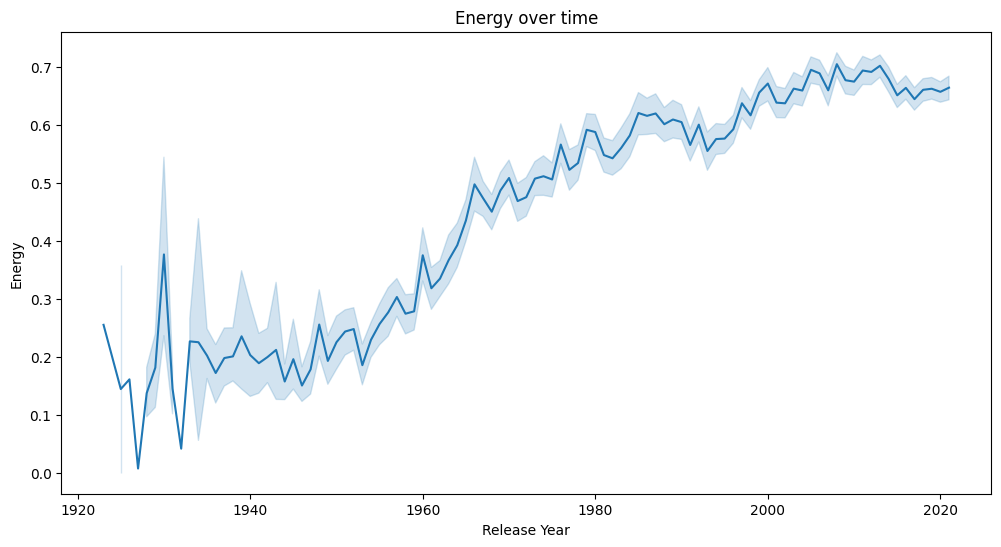

In [97]:
# 22. Visualización: Energía a lo Largo del Tiempo
# Se visualiza el cambio de la 'energía' de las canciones a lo largo de los años.
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_sql,
    x='release_year',
    y='energy'
)

plt.title('Energy over time')

plt.xlabel('Release Year')

plt.ylabel('Energy')

plt.show()

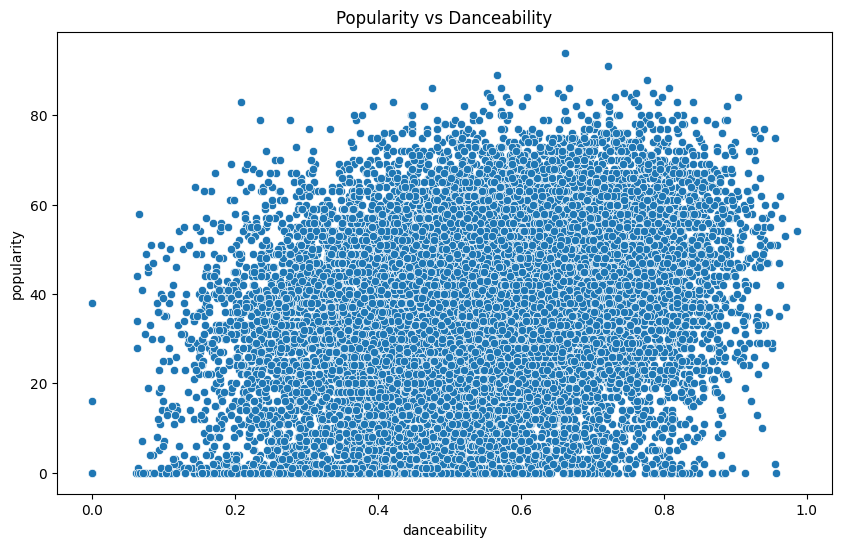

In [98]:
# 23. Visualización: Popularidad vs. Bailabilidad
# Se explora la relación entre 'danceability' y 'popularity'.
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_sql,
    x='danceability',
    y='popularity'
)

plt.title('Popularity vs Danceability')

plt.show()

In [99]:
# 24. Cálculo de Matriz de Correlación
# Se calcula la correlación entre varias características numéricas.
corr = df_sql[[
    'popularity',
    'danceability',
    'energy',
    'valence',
    'tempo'
]].corr()

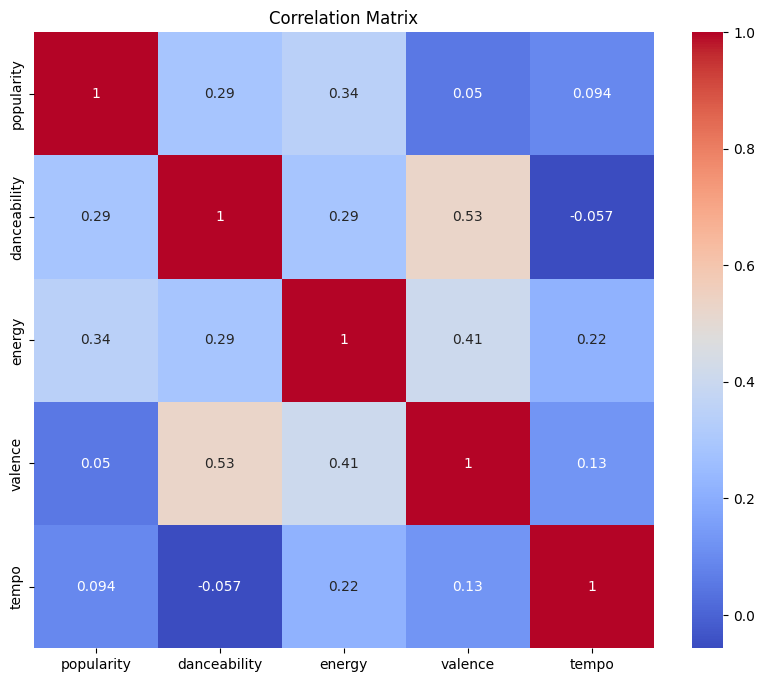

In [100]:
# 42. Visualización: Mapa de Calor de Correlaciones
# Se visualiza la matriz de correlación como un mapa de calor.
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [101]:
# 26. Exportación del Conjunto de Datos Analítico
# Se guarda el DataFrame resultante de la consulta SQL en un archivo CSV.
df_sql.to_csv(
    '../exports/analytical_dataset.csv',
    index=False
)

In [102]:
# 44. Confirmación de Exportación
print('Dataset exportado correctamente')

Dataset exportado correctamente


### Gráfico 4: Distribución de la Popularidad

In [107]:
# Histograma de la popularidad
fig_hist = px.histogram(
    df_analytical,
    x='popularity',
    nbins=50,
    title='Distribución de la Popularidad de las Canciones'
)
fig_hist.show()

NameError: name 'df_analytical' is not defined